# Dimensionality Expansion

Visualise the distribution of $x_{hd}$ components before and after sensor trace
expansion. For a given $(p, d)$:

1. **Raw sensor traces** (8 channels)
   - Histograms of z-scored $x_{hd}$ for 5 random samples
   - Bivariate heatmaps + correlation for 5 random pairs

2. **Expanded to 176 traces** ($\partial^{1-7}$ + 56R + 56D)
   - Same histogram and heatmap diagnostics

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from tools import load
from math import comb
import torch


def backward_diff_array(y, h, n):
    """n-th backward finite difference (zero-padded to preserve length)."""
    coeffs = np.array([(-1)**k * comb(n, k) for k in range(n + 1)])
    raw = np.convolve(y, coeffs, mode='valid') / h**n
    return np.concatenate([np.zeros(n), raw])


device = torch.device('mps' if torch.backends.mps.is_available() else
                       'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


In [12]:
filename = '1_600_20'
sensor_data, sequence, times_sec, sequence_sec = load(filename, reduced=True)
h = np.median(np.diff(times_sec))
n_sensors = sensor_data.shape[1]

# Labels
labels = np.zeros_like(times_sec)
for i in range(len(sequence_sec)):
    try:
        flag = (times_sec > sequence_sec[i]) & (times_sec < sequence_sec[i + 1])
    except IndexError:
        flag = (times_sec > sequence_sec[i])
    labels[flag] = int(sequence[i][1])

labeled_mask = labels > 0
n_samples = sensor_data.shape[0]

print(f"Sensor data: {sensor_data.shape}  ({n_sensors} sensors)")
print(f"Labeled samples: {np.sum(labeled_mask)}")

Sensor data: (11691, 8)  (8 sensors)
Labeled samples: 11392


In [13]:
# Expansion helpers
def expand_with_derivatives(data, h, max_order):
    if max_order == 0:
        return data.copy()
    derivs = []
    for order in range(1, max_order + 1):
        d = np.apply_along_axis(
            lambda col: backward_diff_array(col, h, order), axis=0, arr=data)
        derivs.append(d)
    return np.hstack([data] + derivs)


# Pair pools
rng_pairs = np.random.default_rng(0)
all_ordered_pairs = [(i, j) for i in range(n_sensors) for j in range(n_sensors) if i != j]
ratio_pairs = [all_ordered_pairs[i] for i in rng_pairs.permutation(len(all_ordered_pairs))]
diff_pairs  = [all_ordered_pairs[i] for i in rng_pairs.permutation(len(all_ordered_pairs))]

# Raw (8 traces)
x_raw = sensor_data.copy()

# 176-trace expansion
x_d1234567 = expand_with_derivatives(sensor_data, h, max_order=7)  # 64 cols
r56 = np.column_stack([sensor_data[:, i] / (sensor_data[:, j] + 1e-8) for i, j in ratio_pairs[:56]])
d56 = np.column_stack([sensor_data[:, i] - sensor_data[:, j] for i, j in diff_pairs[:56]])
x_176 = np.hstack([x_d1234567, r56, d56])

print(f"Raw:      {x_raw.shape}")
print(f"Expanded: {x_176.shape}")

Raw:      (11691, 8)
Expanded: (11691, 176)


In [14]:
# HD projection parameters
p = 0.2
d = 0.2
n_hd = 10_000
k = int(d * n_hd)

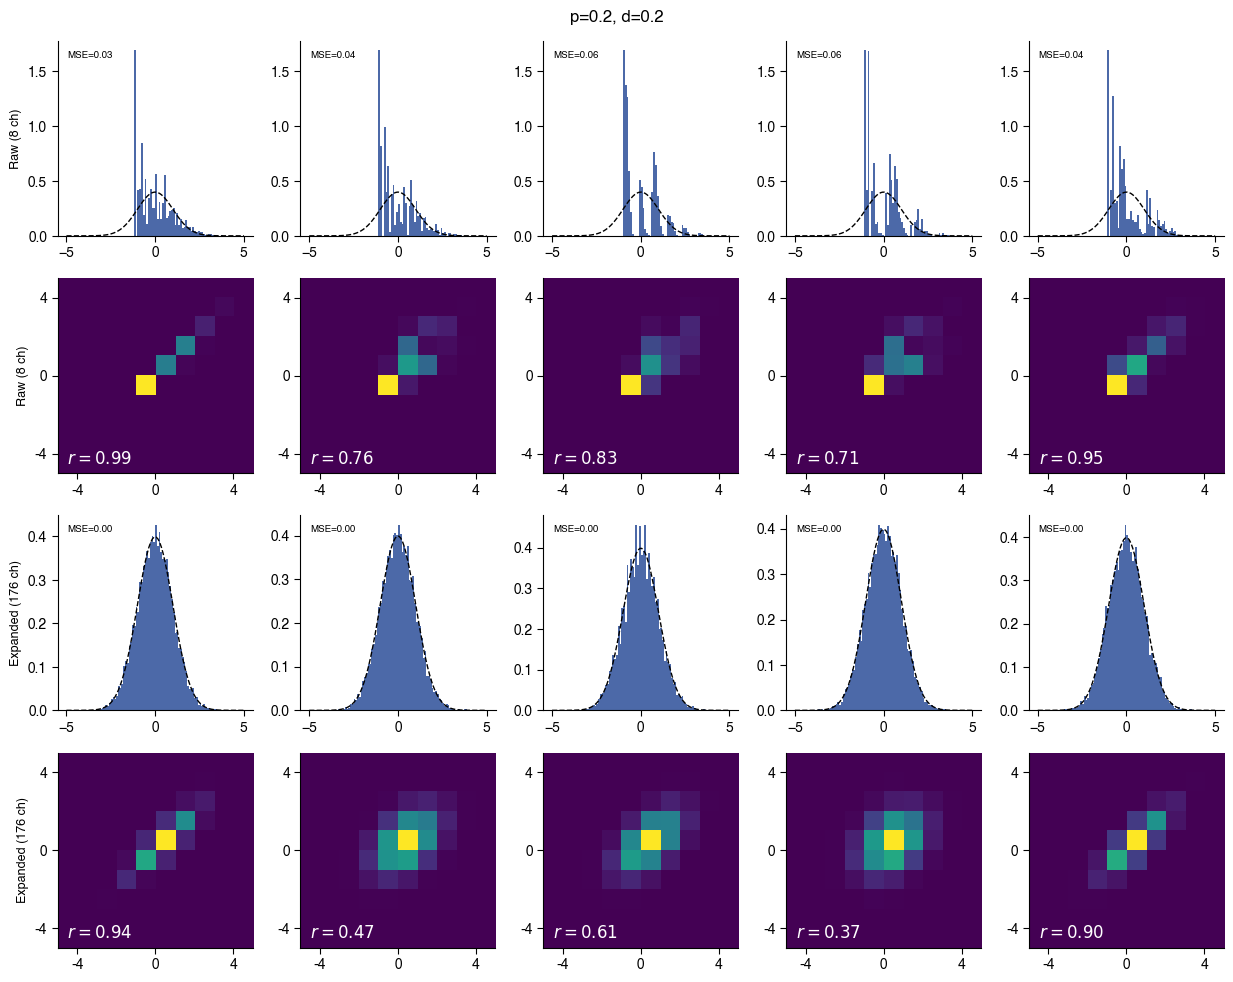

In [15]:
n_col = 5
res = 10
z_range = np.linspace(-5, 5, 100)
normal_pdf = norm.pdf(z_range)
box = np.linspace(-5, 5, res)

# HD projections
n_dense_raw = x_raw.shape[1]
n_dense_exp = x_176.shape[1]

x_raw_t = torch.tensor(x_raw, dtype=torch.float32, device=device)
W_raw = torch.bernoulli(torch.full((n_hd, n_dense_raw), p, device=device))
x_hd_raw = x_raw_t @ W_raw.T

x_exp_t = torch.tensor(x_176, dtype=torch.float32, device=device)
W_exp = torch.bernoulli(torch.full((n_hd, n_dense_exp), p, device=device))
x_hd_exp = x_exp_t @ W_exp.T

# Random indices
hist_idx = np.random.randint(0, n_samples, size=n_col)
pair_indices = np.array([np.random.choice(n_samples, size=2, replace=False) for _ in range(n_col)])

fig, axes = plt.subplots(4, n_col, figsize=(2.5*n_col, 10))

for x_hd_cur, label, row_hist, row_hmap in [
    (x_hd_raw, f'Raw ({n_dense_raw} ch)', 0, 1),
    (x_hd_exp, f'Expanded ({n_dense_exp} ch)', 2, 3),
]:
    # --- histograms ---
    vals = x_hd_cur[hist_idx, :].cpu().numpy()
    for j in range(n_col):
        ax = axes[row_hist, j]
        mean = np.mean(vals[j, :])
        std = np.std(vals[j, :])
        if std == 0:
            std = 1e-6
        values_recast = (vals[j, :] - mean) / std
        counts, bin_edges, _ = ax.hist(values_recast, bins=100, range=(-5, 5), density=True, color='C0')
        ax.plot(z_range, normal_pdf, '--', color='black', linewidth=1.)

        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        pdf_at_centers = norm.pdf(bin_centers)
        mse = np.mean((counts - pdf_at_centers)**2)
        ax.text(0.05, 0.95, f'MSE={mse:.2f}', transform=ax.transAxes,
                ha='left', va='top', fontsize=7)
        if j == 0:
            ax.set_ylabel(label, fontsize=9)

    # --- heatmaps ---
    for j in range(n_col):
        ax = axes[row_hmap, j]
        idx1 = pair_indices[j][0]
        idx2 = pair_indices[j][1]
        x_hd1 = x_hd_cur[idx1].cpu().numpy()
        x_hd2 = x_hd_cur[idx2].cpu().numpy()
        mean1, std1 = np.mean(x_hd1), np.std(x_hd1)
        mean2, std2 = np.mean(x_hd2), np.std(x_hd2)
        if std1 == 0:
            std1 = 1e-6
        if std2 == 0:
            std2 = 1e-6
        v1 = (x_hd1 - mean1) / std1
        v2 = (x_hd2 - mean2) / std2
        corr = np.corrcoef(v1, v2)[0, 1]
        hmap = np.zeros((res, res))
        for m in range(n_hd):
            x1 = (v1[m] < box) & (v1[m] >= box - 10./res)
            x2 = (v2[m] < box) & (v2[m] >= box - 10./res)
            hmap[x1, x2] += 1

        ax.imshow(hmap, origin='lower')
        ax.set_xticks([res/10 - 0.5, res/2 - 0.5, 9*res/10 - 0.5], labels=[-4, 0, 4])
        ax.set_yticks([res/10 - 0.5, res/2 - 0.5, 9*res/10 - 0.5], labels=[-4, 0, 4])
        ax.text(0.05, 0.05, f'$r={corr:.2f}$', transform=ax.transAxes, color='white')
        if j == 0:
            ax.set_ylabel(label, fontsize=9)

fig.suptitle(f'p={p}, d={d}', fontsize=12)
plt.tight_layout()
plt.show()